# Notebook 22: Clinical & Biomedical Imaging — Modeling

**BINF 4002 — Machine Learning for Health | Lecture 22 Companion**

---

## Overview

This notebook covers three major modeling paradigms for medical imaging, using **real data throughout**:

1. **Classification:** Transfer learning & the Transfusion question (ChestMNIST — real chest X-rays)
2. **Segmentation:** U-Net with skip connections vs. baseline (Kvasir-SEG — real polyp images)
3. **Multi-instance learning:** Attention-based aggregation (PathMNIST — real H&E pathology tiles)

Plus: augmentation validity comparison on real medical vs. natural images.

**Key theme:** You already know CNNs, encoders, and attention. This notebook focuses on
what's *different* about applying them to medical images — and where standard assumptions break.

**Data sources:**
- [MedMNIST](https://medmnist.com/) — standardized medical image benchmarks (pip installable)
- [Kvasir-SEG](https://datasets.simula.no/kvasir-seg/) — 1000 polyp images + expert segmentation masks
- [scikit-image](https://scikit-image.org/) — natural images for comparison

In [1]:
# (pip install handled by the book's isolated env)

/bin/bash: line 1: pip: command not found


In [2]:
## SETUP
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import os
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import torchvision
import torchvision.models as models
import torchvision.transforms as T

from sklearn.metrics import roc_auc_score
from scipy.ndimage import rotate as ndimage_rotate, gaussian_filter
from PIL import Image

os.makedirs("figures", exist_ok=True)

sns.set_style("whitegrid")
PALETTE = sns.color_palette("colorblind")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 10,
})

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
rng = np.random.default_rng(42)
torch.manual_seed(42)

# --- MedMNIST ---
import medmnist
from medmnist import ChestMNIST, PathMNIST

print(f"PyTorch {torch.__version__}, device: {device}")
print(f"medmnist {medmnist.__version__}")
print("Setup complete.")

ModuleNotFoundError: No module named 'seaborn'

---
## Part 1: Transfer Learning & The Transfusion Question

We use **ChestMNIST** (real chest X-rays from NIH ChestX-ray14, resized to 64×64) for
classification experiments. Then we examine what ImageNet-pretrained features look like
on these real medical images.

Recall L21's five-question framework: the *physics* of medical images (grayscale, local texture,
standardized views) differs fundamentally from natural images. This matters for transfer learning.

In [3]:
# ==============================================================================
# Load real chest X-ray data (ChestMNIST)
# ==============================================================================
# ChestMNIST: 14-label multi-label classification from NIH ChestX-ray14
# We use size=64 for fast training; convert multi-label to binary (any finding vs. normal)

import os
os.makedirs('./medmnist_data', exist_ok=True)

cxr_train = ChestMNIST(split='train', download=True, size=64, root='./medmnist_data')
cxr_val   = ChestMNIST(split='val',   download=True, size=64, root='./medmnist_data')
cxr_test  = ChestMNIST(split='test',  download=True, size=64, root='./medmnist_data')

# Convert to numpy arrays
def medmnist_to_numpy(dataset):
    imgs = np.array([np.array(dataset[i][0]) for i in range(len(dataset))])
    labels = np.array([dataset[i][1] for i in range(len(dataset))])
    # Convert to float [0,1], handle shape
    if imgs.ndim == 4 and imgs.shape[-1] in [1, 3]:
        imgs = imgs.mean(axis=-1)  # to grayscale
    elif imgs.ndim == 3 and imgs.shape[-1] in [1, 3]:
        imgs = imgs.mean(axis=-1)
    imgs = imgs.astype(np.float32) / 255.0
    # Binary: any finding = 1, no finding = 0
    binary_labels = (labels.sum(axis=1) > 0).astype(np.float32)
    return imgs, binary_labels

X_train, y_train = medmnist_to_numpy(cxr_train)
X_val, y_val     = medmnist_to_numpy(cxr_val)
X_test, y_test   = medmnist_to_numpy(cxr_test)

print(f"Train: {X_train.shape}, positive rate = {y_train.mean():.2f}")
print(f"Val:   {X_val.shape}, positive rate = {y_val.mean():.2f}")
print(f"Test:  {X_test.shape}, positive rate = {y_test.mean():.2f}")

# Show examples
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    idx_pos = np.where(y_train == 1)[0][i]
    idx_neg = np.where(y_train == 0)[0][i]
    axes[0, i].imshow(X_train[idx_neg], cmap="gray", vmin=0, vmax=1)
    axes[0, i].set_title("Normal", fontsize=8)
    axes[0, i].axis("off")
    axes[1, i].imshow(X_train[idx_pos], cmap="gray", vmin=0, vmax=1)
    axes[1, i].set_title("Finding", fontsize=8)
    axes[1, i].axis("off")
plt.suptitle("Real Chest X-Rays (ChestMNIST, 64x64)", fontweight="bold")
plt.tight_layout()
plt.show()

NameError: name 'ChestMNIST' is not defined

## Figure 1: Transfer Learning Feature Visualization — Natural vs. Medical

**LECTURE FIGURE**

We pass **the same ImageNet-pretrained DenseNet** over a natural image (cat) and a real chest
X-ray, then visualize feature maps at three depths. The comparison reveals why transfer
learning from ImageNet offers limited benefit for medical images:

- **Early layers** (edges, textures): similar activation patterns on both — these transfer well
- **Late layers** (object parts): meaningful on the cat (fur, ears, eyes), but **random noise on the X-ray** — these need to be retrained or discarded

This is the visual intuition behind the Transfusion finding (Raghu et al., 2019).


In [4]:
# ==============================================================================
# Figure 1: Feature comparison — Top cat-activated channels on both images
# ==============================================================================
import skimage.data

densenet = models.densenet121(weights="IMAGENET1K_V1")
densenet.eval()
densenet = densenet.to(device)

# Register hooks
features = {}
hooks = []
def make_hook(name):
    def hook(module, input, output):
        features[name] = output.detach().cpu()
    return hook
for name, module in [("early", densenet.features.denseblock1),
                      ("middle", densenet.features.denseblock2),
                      ("late", densenet.features.denseblock4)]:
    hooks.append(module.register_forward_hook(make_hook(name)))

mean_t = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
std_t = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)

# --- Natural image (cat, full RGB, 224x224) ---
cat = skimage.data.chelsea()
h, w = cat.shape[:2]; s = min(h, w)
cat_crop = cat[(h-s)//2:(h+s)//2, (w-s)//2:(w+s)//2]
cat_224 = np.array(Image.fromarray(cat_crop).resize((224, 224))).astype(np.float32) / 255.0
cat_tensor = (torch.tensor(cat_224).permute(2,0,1).unsqueeze(0) - mean_t) / std_t

# --- Chest X-ray (real, replicated to 3ch, 224x224) ---
xray_idx = np.where(y_train == 1)[0][0]
xray_img = X_train[xray_idx]
xray_tensor = torch.tensor(xray_img).unsqueeze(0).unsqueeze(0).repeat(1,3,1,1)
xray_tensor = F.interpolate(xray_tensor, size=(224,224), mode="bilinear")
xray_tensor = (xray_tensor - mean_t) / std_t

# Extract features
with torch.no_grad():
    _ = densenet(cat_tensor.to(device))
cat_feats = {k: v.clone() for k, v in features.items()}

with torch.no_grad():
    _ = densenet(xray_tensor.to(device))
xray_feats = {k: v.clone() for k, v in features.items()}

for h in hooks:
    h.remove()

# --- Figure: top-activated channels (selected by cat) + quantitative panel ---
layers = [("early", "Early (Block 1)"), ("middle", "Middle (Block 2)"), ("late", "Late (Block 4)")]
N_SHOW = 5

fig = plt.figure(figsize=(18, 10))
gs_main = gridspec.GridSpec(3, 2, width_ratios=[3, 1], wspace=0.15)

for depth_i, (layer_key, layer_label) in enumerate(layers):
    cf = cat_feats[layer_key][0]    # (C, H, W)
    xf = xray_feats[layer_key][0]

    # Rank channels by mean activation on the cat
    cat_act = cf.abs().mean(dim=(1,2))  # (C,)
    top_idx = cat_act.argsort(descending=True)[:N_SHOW].numpy()

    # Left panel: feature maps (2 rows x N_SHOW+1 cols)
    gs_left = gridspec.GridSpecFromSubplotSpec(2, N_SHOW + 1, subplot_spec=gs_main[depth_i, 0],
                                               hspace=0.05, wspace=0.05)

    # Input images
    ax_cat_in = fig.add_subplot(gs_left[0, 0])
    ax_cat_in.imshow(cat_crop)
    ax_cat_in.axis("off")
    if depth_i == 0:
        ax_cat_in.set_title("Input", fontsize=8)
    ax_cat_in.set_ylabel(layer_label, fontsize=9, rotation=0, labelpad=65, va="center")

    ax_xray_in = fig.add_subplot(gs_left[1, 0])
    ax_xray_in.imshow(xray_img, cmap="gray", vmin=0, vmax=1)
    ax_xray_in.axis("off")

    # Feature maps — same channels, shared color scale per channel
    for col_i, ci in enumerate(top_idx):
        vmin = min(cf[ci].min().item(), xf[ci].min().item())
        vmax = max(cf[ci].max().item(), xf[ci].max().item())

        ax_c = fig.add_subplot(gs_left[0, col_i + 1])
        ax_c.imshow(cf[ci].numpy(), cmap="inferno", vmin=vmin, vmax=vmax)
        ax_c.axis("off")
        if depth_i == 0:
            ax_c.set_title(f"Ch {ci}", fontsize=7)

        ax_x = fig.add_subplot(gs_left[1, col_i + 1])
        ax_x.imshow(xf[ci].numpy(), cmap="inferno", vmin=vmin, vmax=vmax)
        ax_x.axis("off")

    # Right panel: bar chart of mean activation
    gs_right = gridspec.GridSpecFromSubplotSpec(1, 1, subplot_spec=gs_main[depth_i, 1])
    ax_bar = fig.add_subplot(gs_right[0])

    cat_top_acts = cat_act[top_idx].numpy()
    xray_act = xf.abs().mean(dim=(1,2))
    xray_top_acts = xray_act[top_idx].numpy()

    x = np.arange(N_SHOW)
    ax_bar.barh(x + 0.15, cat_top_acts, height=0.3, color=PALETTE[0], label="Natural", alpha=0.85)
    ax_bar.barh(x - 0.15, xray_top_acts, height=0.3, color=PALETTE[3], label="X-ray", alpha=0.85)
    ax_bar.set_yticks(x)
    ax_bar.set_yticklabels([f"Ch {ci}" for ci in top_idx], fontsize=7)
    ax_bar.set_xlabel("Mean |activation|", fontsize=8)
    ax_bar.tick_params(labelsize=7)
    ax_bar.invert_yaxis()
    if depth_i == 0:
        ax_bar.legend(fontsize=7, loc="lower right")
        ax_bar.set_title("Activation\nstrength", fontsize=8)

# Row labels
fig.text(0.01, 0.83, "Natural", fontsize=9, fontweight="bold", color=PALETTE[0], va="center")
fig.text(0.01, 0.76, "X-ray", fontsize=9, fontweight="bold", color=PALETTE[3], va="center")
fig.text(0.01, 0.55, "Natural", fontsize=9, fontweight="bold", color=PALETTE[0], va="center")
fig.text(0.01, 0.48, "X-ray", fontsize=9, fontweight="bold", color=PALETTE[3], va="center")
fig.text(0.01, 0.27, "Natural", fontsize=9, fontweight="bold", color=PALETTE[0], va="center")
fig.text(0.01, 0.20, "X-ray", fontsize=9, fontweight="bold", color=PALETTE[3], va="center")

fig.suptitle("ImageNet DenseNet Features: Channels That Activate Most on Natural Image\n"
             "(same channels shown on X-ray — shared color scale per channel)",
             fontsize=12, fontweight="bold", y=1.01)
plt.savefig("figures/fig1_feature_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# Print quantitative summary
print("Mean |activation| across ALL channels at each depth:")
for layer_key, layer_label in layers:
    cat_mean = cat_feats[layer_key][0].abs().mean().item()
    xray_mean = xray_feats[layer_key][0].abs().mean().item()
    ratio = cat_mean / max(xray_mean, 1e-8)
    print(f"  {layer_label}: cat={cat_mean:.3f}, xray={xray_mean:.3f}, ratio={ratio:.1f}x")
print()
print("Key: at late layers, channels selected by cat have MUCH lower activation on X-ray.")
print("The network has strong opinions about the cat (in-distribution) but not the X-ray.")

ModuleNotFoundError: No module named 'skimage'

---
## Figure 2: Fine-Tuning Strategy Comparison (Transfusion-Inspired)

**LECTURE FIGURE**

We train on **real ChestMNIST X-rays** with four strategies. The Transfusion finding:
lightweight models and from-scratch training often reach comparable final performance,
even though pre-trained models converge faster.

We use a subset of the training data for speed (2000 images).

In [5]:
# ==============================================================================
# Models + training on real ChestMNIST data
# ==============================================================================

class SimpleCNN(nn.Module):
    # Small CNN for binary classification on 64x64 grayscale
    def __init__(self):
        super().__init__()
        self.early = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2))
        self.late = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d(1))
        self.classifier = nn.Linear(64, 1)
    def forward(self, x):
        x = self.late(self.early(x))
        return self.classifier(x.view(x.size(0), -1)).squeeze(-1)

class LightweightCNN(nn.Module):
    # Even smaller - Transfusion showed these can match larger architectures
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 8, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(8, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 16, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d(1))
        self.classifier = nn.Linear(16, 1)
    def forward(self, x):
        return self.classifier(self.features(x).view(x.size(0), -1)).squeeze(-1)

def train_and_evaluate(model, X_tr, y_tr, X_v, y_v, epochs=20, lr=1e-3):
    X_tr_t = torch.tensor(X_tr[:, None, :, :])
    y_tr_t = torch.tensor(y_tr, dtype=torch.float32)
    X_v_t = torch.tensor(X_v[:, None, :, :]).to(device)
    loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=64, shuffle=True)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    criterion = nn.BCEWithLogitsLoss()
    model = model.to(device)
    val_aucs = []
    for epoch in range(epochs):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
        model.eval()
        with torch.no_grad():
            preds = torch.sigmoid(model(X_v_t)).cpu().numpy()
        try:
            val_aucs.append(roc_auc_score(y_v, preds))
        except ValueError:
            val_aucs.append(0.5)
    return val_aucs

# Use a subset for speed
N_TRAIN = min(2000, len(X_train))
X_tr_sub, y_tr_sub = X_train[:N_TRAIN], y_train[:N_TRAIN]

# Strategy (a): simulate pre-training then fine-tune all
print("(a) Fine-tune all layers (pre-trained simulation)...")
model_a = SimpleCNN()
_ = train_and_evaluate(model_a, X_tr_sub, y_tr_sub, X_val, y_val, epochs=10, lr=1e-3)
aucs_a = train_and_evaluate(model_a, X_tr_sub, y_tr_sub, X_val, y_val, epochs=20, lr=3e-4)

# Strategy (b): fine-tune last block only
print("(b) Fine-tune last block only...")
model_b = SimpleCNN()
_ = train_and_evaluate(model_b, X_tr_sub, y_tr_sub, X_val, y_val, epochs=10, lr=1e-3)
for param in model_b.early.parameters():
    param.requires_grad = False
aucs_b = train_and_evaluate(model_b, X_tr_sub, y_tr_sub, X_val, y_val, epochs=20, lr=3e-4)

# Strategy (c): from scratch, same architecture
print("(c) From scratch (same arch)...")
model_c = SimpleCNN()
aucs_c = train_and_evaluate(model_c, X_tr_sub, y_tr_sub, X_val, y_val, epochs=20, lr=1e-3)

# Strategy (d): lightweight from scratch
print("(d) Lightweight from scratch...")
model_d = LightweightCNN()
aucs_d = train_and_evaluate(model_d, X_tr_sub, y_tr_sub, X_val, y_val, epochs=20, lr=1e-3)

n_params_std = sum(p.numel() for p in SimpleCNN().parameters())
n_params_light = sum(p.numel() for p in LightweightCNN().parameters())
print(f"SimpleCNN: {n_params_std:,} params | LightweightCNN: {n_params_light:,} params")

NameError: name 'nn' is not defined

NameError: name 'aucs_a' is not defined

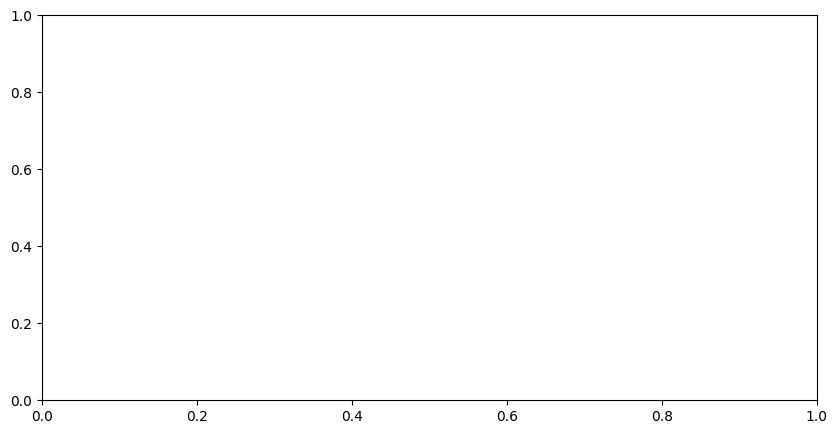

In [6]:
# --- Plot learning curves ---
fig, ax = plt.subplots(figsize=(10, 5))
epochs_range = range(1, 21)
ax.plot(epochs_range, aucs_a, label="(a) Fine-tune all", color=PALETTE[0], linewidth=2)
ax.plot(epochs_range, aucs_b, label="(b) Last block only", color=PALETTE[1], linewidth=2, linestyle="--")
ax.plot(epochs_range, aucs_c, label="(c) From scratch (same)", color=PALETTE[2], linewidth=2, linestyle=":")
ax.plot(epochs_range, aucs_d, label=f"(d) Lightweight ({n_params_light:,} params)", color=PALETTE[3], linewidth=2, linestyle="-.")
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation AUC")
ax.set_title("Transfusion-Inspired: Fine-Tuning on Real Chest X-Rays", fontweight="bold")
ax.legend(fontsize=10)
ax.set_ylim(0.4, 1.0)
plt.tight_layout()
plt.savefig("figures/fig2_finetuning_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Final AUCs: (a) {aucs_a[-1]:.3f}  (b) {aucs_b[-1]:.3f}  (c) {aucs_c[-1]:.3f}  (d) {aucs_d[-1]:.3f}")

---
## Part 2: Segmentation with U-Net (Real Kvasir-SEG Data)

We download the **Kvasir-SEG** dataset: 1000 real colonoscopy images with expert-annotated polyp
segmentation masks (Jha et al., MMM 2020, CC-BY license).

This is the real clinical problem: segment polyps from colonoscopy images to help gastroenterologists.
The polyps are small, irregular, and the class imbalance is extreme — exactly where Dice loss matters.

/home/mmd/Dropbox/Teaching/BINF4002/2026_01/repo_jupyterbook/.venv/lib/python3.11/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'datasets.simula.no'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Download complete.
Found 1000 images, 1000 masks


Segmentation: 800 train, 200 val
Polyp pixel fraction (train): 0.151


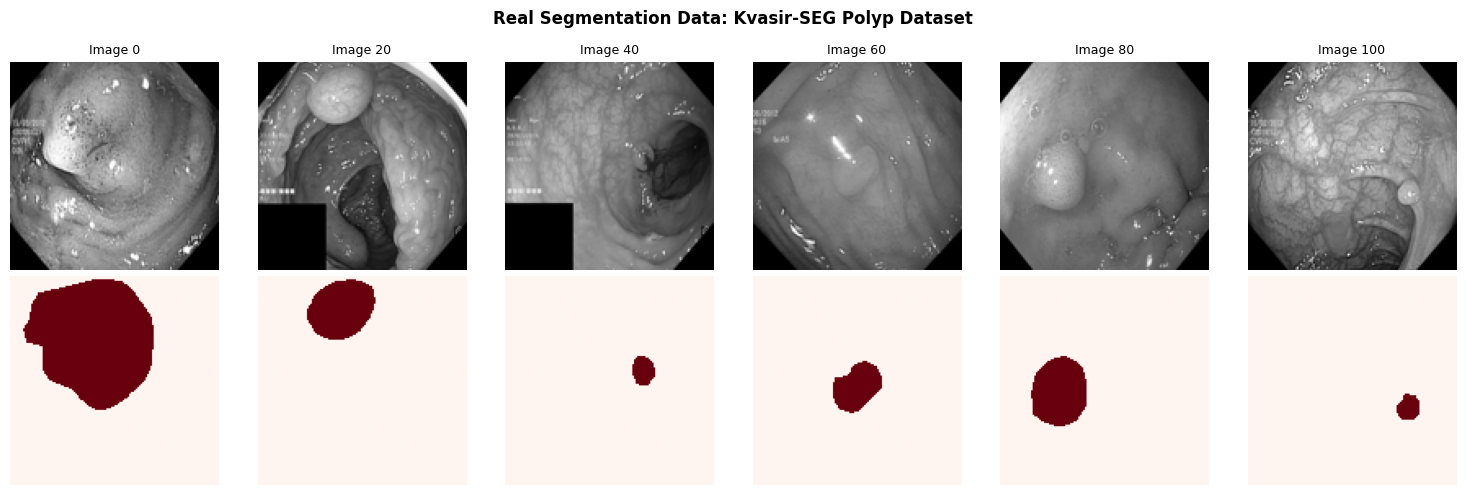

In [7]:
# ==============================================================================
# Download and load Kvasir-SEG (real polyp segmentation data)
# ==============================================================================
import zipfile, glob, os
import requests
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

KVASIR_DIR = './kvasir_seg'
IMG_SIZE = 128  # resize for fast training

if not os.path.exists(os.path.join(KVASIR_DIR, 'Kvasir-SEG')):
    url = 'https://datasets.simula.no/downloads/kvasir-seg.zip'
    print(f'Downloading Kvasir-SEG (~46 MB)...')
    response = requests.get(url, verify=False)
    os.makedirs(KVASIR_DIR, exist_ok=True)
    with open('/tmp/kvasir-seg.zip', 'wb') as f:
        f.write(response.content)
    with zipfile.ZipFile('/tmp/kvasir-seg.zip', 'r') as z:
        z.extractall(KVASIR_DIR)
    print('Download complete.')
else:
    print('Kvasir-SEG already downloaded.')

# Load images and masks
img_paths = sorted(glob.glob(os.path.join(KVASIR_DIR, '**/images/*.jpg'), recursive=True))
mask_paths = sorted(glob.glob(os.path.join(KVASIR_DIR, '**/masks/*.jpg'), recursive=True))
print(f"Found {len(img_paths)} images, {len(mask_paths)} masks")

# Load and resize
seg_images, seg_masks = [], []
for ip, mp in zip(img_paths, mask_paths):
    img = np.array(Image.open(ip).convert('L').resize((IMG_SIZE, IMG_SIZE))) / 255.0
    mask = np.array(Image.open(mp).convert('L').resize((IMG_SIZE, IMG_SIZE), Image.NEAREST)) / 255.0
    mask = (mask > 0.5).astype(np.float32)
    seg_images.append(img.astype(np.float32))
    seg_masks.append(mask)

seg_images = np.array(seg_images)
seg_masks = np.array(seg_masks)

# Train/val split
n_train = int(0.8 * len(seg_images))
seg_X_train, seg_y_train = seg_images[:n_train], seg_masks[:n_train]
seg_X_val, seg_y_val = seg_images[n_train:], seg_masks[n_train:]

print(f"Segmentation: {seg_X_train.shape[0]} train, {seg_X_val.shape[0]} val")
print(f"Polyp pixel fraction (train): {seg_y_train.mean():.3f}")

# Show examples
fig, axes = plt.subplots(2, 6, figsize=(15, 5))
for i in range(6):
    axes[0, i].imshow(seg_X_train[i*20], cmap="gray", vmin=0, vmax=1)
    axes[0, i].set_title(f"Image {i*20}", fontsize=9)
    axes[0, i].axis("off")
    axes[1, i].imshow(seg_y_train[i*20], cmap="Reds", vmin=0, vmax=1)
    axes[1, i].axis("off")
axes[0, 0].set_ylabel("Colonoscopy", fontsize=10)
axes[1, 0].set_ylabel("Expert mask", fontsize=10)
plt.suptitle("Real Segmentation Data: Kvasir-SEG Polyp Dataset", fontweight="bold")
plt.tight_layout()
plt.savefig("figures/fig_real_segmentation.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
# ==============================================================================
# U-Net and No-Skip Baseline (4 stages + BatchNorm)
# ==============================================================================
# Key detail: We've made the network deeper (4 stages instead of 3).
# The bottleneck is now 8x8 (16x compression). This severe loss of spatial
# resolution makes the skip connections absolutely critical for reconstructing
# fine boundaries.

def conv_block(in_ch, out_ch):
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(),
        nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU())

class MiniUNet(nn.Module):
    def __init__(self, use_skip=True):
        super().__init__()
        self.use_skip = use_skip
        # Encoder: 128 -> 64 -> 32 -> 16 -> 8
        self.enc1 = conv_block(1, 32)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = conv_block(32, 64)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = conv_block(64, 128)
        self.pool3 = nn.MaxPool2d(2)
        self.enc4 = conv_block(128, 256)
        self.pool4 = nn.MaxPool2d(2)

        # Bottleneck (8x8)
        self.bottleneck = conv_block(256, 512)

        # Decoder: 8 -> 16 -> 32 -> 64 -> 128
        self.up4 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec4 = conv_block(512 if use_skip else 256, 256)
        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3 = conv_block(256 if use_skip else 128, 128)
        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = conv_block(128 if use_skip else 64, 64)
        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = conv_block(64 if use_skip else 32, 32)
        self.final = nn.Conv2d(32, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        e4 = self.enc4(self.pool3(e3))

        b = self.bottleneck(self.pool4(e4))

        d4 = self.up4(b)
        d4 = self.dec4(torch.cat([d4, e4], 1) if self.use_skip else d4)
        d3 = self.up3(d4)
        d3 = self.dec3(torch.cat([d3, e3], 1) if self.use_skip else d3)
        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, e2], 1) if self.use_skip else d2)
        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], 1) if self.use_skip else d1)

        return self.final(d1)

print(f"U-Net (skip + BN): {sum(p.numel() for p in MiniUNet(True).parameters()):,} params")
print(f"No-skip (BN):      {sum(p.numel() for p in MiniUNet(False).parameters()):,} params")
print(f"Bottleneck: 128x128 -> 8x8 (16x compression)")


NameError: name 'nn' is not defined

In [9]:
# ==============================================================================
# Segmentation training loop (augmentation + LR scheduling)
# ==============================================================================
import torchvision.transforms.functional as TF

def dice_score(pred, target, threshold=0.5):
    pred_bin = (pred > threshold).float()
    intersection = (pred_bin * target).sum()
    return (2 * intersection + 1e-7) / (pred_bin.sum() + target.sum() + 1e-7)

def dice_loss(pred, target):
    pred_sig = torch.sigmoid(pred)
    intersection = (pred_sig * target).sum()
    return 1 - (2 * intersection + 1e-7) / (pred_sig.sum() + target.sum() + 1e-7)

def augment_seg_batch(imgs, masks):
    """Augment segmentation pairs: flips, rotation, scale, brightness."""
    aug_imgs, aug_masks = [], []
    for img, mask in zip(imgs, masks):
        # Random horizontal flip
        if torch.rand(1).item() > 0.5:
            img = torch.flip(img, [-1])
            mask = torch.flip(mask, [-1])
        # Random vertical flip
        if torch.rand(1).item() > 0.5:
            img = torch.flip(img, [-2])
            mask = torch.flip(mask, [-2])
        # Random rotation (-30 to +30 degrees)
        if torch.rand(1).item() > 0.3:
            angle = torch.empty(1).uniform_(-30, 30).item()
            img = TF.rotate(img, angle)
            mask = TF.rotate(mask, angle)
        # Random scale (0.8x to 1.2x) via affine
        if torch.rand(1).item() > 0.5:
            scale = torch.empty(1).uniform_(0.8, 1.2).item()
            img = TF.affine(img, angle=0, translate=[0, 0], scale=scale, shear=0)
            mask = TF.affine(mask, angle=0, translate=[0, 0], scale=scale, shear=0)
        # Random brightness (image only, not mask)
        if torch.rand(1).item() > 0.5:
            factor = torch.empty(1).uniform_(0.7, 1.3).item()
            img = torch.clamp(img * factor, 0, 1)
        aug_imgs.append(img)
        aug_masks.append(mask)
    return torch.stack(aug_imgs), torch.stack(aug_masks)

def train_segmentation(model, X_tr, y_tr, X_v, y_v, epochs=50, lr=1e-3, loss_type="ce+dice"):
    """Train with cosine annealing LR and augmentation. Returns per-epoch val Dice."""
    X_tr_t = torch.tensor(X_tr[:, None, :, :])
    y_tr_t = torch.tensor(y_tr[:, None, :, :])
    X_v_t = torch.tensor(X_v[:, None, :, :]).to(device)
    y_v_t = torch.tensor(y_v[:, None, :, :]).to(device)
    loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=16, shuffle=True)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)
    bce = nn.BCEWithLogitsLoss()
    model = model.to(device)
    val_dices = []
    for epoch in range(epochs):
        model.train()
        for xb, yb in loader:
            xb, yb = augment_seg_batch(xb, yb)
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            pred = model(xb)
            if loss_type == "ce":
                loss = bce(pred, yb)
            elif loss_type == "dice":
                loss = dice_loss(pred, yb)
            else:
                loss = bce(pred, yb) + dice_loss(pred, yb)
            loss.backward()
            optimizer.step()
        scheduler.step()
        model.eval()
        with torch.no_grad():
            val_pred = torch.sigmoid(model(X_v_t))
            d = dice_score(val_pred, y_v_t).item()
        val_dices.append(d)
    return val_dices


ModuleNotFoundError: No module named 'torchvision'

## Figure 3: U-Net vs. No-Skip Baseline on Real Polyp Data

**LECTURE FIGURE**

We train both architectures on 800 real Kvasir-SEG polyp images (128x128) for 50 epochs with
cosine annealing and aggressive augmentation (flips, rotation, scaling, brightness).

**What to look for:** The Dice scores may converge to similar values — polyps in Kvasir-SEG are
relatively large (15% of pixels), so even the bottleneck captures enough for gross localization.
But examine the **qualitative predictions**: the no-skip model produces smoother, less precise
boundaries. Skip connections matter most for **boundary quality**, which Dice (an overlap metric)
is insensitive to. Hausdorff distance would show a larger gap.


In [10]:
print("Training U-Net (with skip connections) on real polyp data...")
unet = MiniUNet(use_skip=True)
dices_unet = train_segmentation(unet, seg_X_train, seg_y_train, seg_X_val, seg_y_val, epochs=50)

print("Training baseline (no skip connections)...")
noskip = MiniUNet(use_skip=False)
dices_noskip = train_segmentation(noskip, seg_X_train, seg_y_train, seg_X_val, seg_y_val, epochs=50)

# --- Plot ---
fig = plt.figure(figsize=(18, 5))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 2])

ax0 = fig.add_subplot(gs[0])
ax0.plot(range(1, 51), dices_unet, label="U-Net (skip)", color=PALETTE[0], linewidth=2)
ax0.plot(range(1, 51), dices_noskip, label="No skip", color=PALETTE[3], linewidth=2, linestyle="--")
ax0.set_xlabel("Epoch")
ax0.set_ylabel("Validation Dice")
ax0.set_title("Training Curves", fontweight="bold")
ax0.legend()

inner_gs = gridspec.GridSpecFromSubplotSpec(4, 4, subplot_spec=gs[1], hspace=0.1, wspace=0.05)
col_titles = ["Input", "Ground Truth", "U-Net", "No-Skip"]

unet.eval(); noskip.eval()
show_idx = np.linspace(0, len(seg_X_val)-1, 4, dtype=int)
X_v_t = torch.tensor(seg_X_val[show_idx, None, :, :]).to(device)
with torch.no_grad():
    pred_unet = torch.sigmoid(unet(X_v_t)).cpu().numpy()
    pred_noskip = torch.sigmoid(noskip(X_v_t)).cpu().numpy()

for row in range(4):
    contents = [
        (seg_X_val[show_idx[row]], "gray"),
        (seg_y_val[show_idx[row]], "Reds"),
        (pred_unet[row, 0], "Reds"),
        (pred_noskip[row, 0], "Reds"),
    ]
    for col, (img, cmap) in enumerate(contents):
        ax = fig.add_subplot(inner_gs[row, col])
        ax.imshow(img, cmap=cmap, vmin=0, vmax=1)
        ax.axis("off")
        if row == 0:
            ax.set_title(col_titles[col], fontsize=9)

fig.suptitle("U-Net vs. No-Skip on Real Polyp Segmentation (Kvasir-SEG)",
             fontsize=13, fontweight="bold", y=1.02)
plt.savefig("figures/fig3_unet_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Final Dice - U-Net: {dices_unet[-1]:.3f} (best: {max(dices_unet):.3f}), No-skip: {dices_noskip[-1]:.3f} (best: {max(dices_noskip):.3f})")

Training U-Net (with skip connections) on real polyp data...


NameError: name 'MiniUNet' is not defined

---
## Figure 4: Loss Function Comparison on Real Data

**LECTURE FIGURE**

We retrain U-Net with CE only, Dice only, and combined — on real polyp data with 50 epochs
and cosine annealing. With longer training, the differences between loss functions become
clearer: CE alone struggles with the class imbalance (polyps are ~15% of pixels), Dice loss
directly optimizes overlap, and the combined loss gets the best of both.


In [11]:
print("Training with CE loss only...")
dices_ce = train_segmentation(MiniUNet(True), seg_X_train, seg_y_train, seg_X_val, seg_y_val, epochs=50, loss_type="ce")
print("Training with Dice loss only...")
dices_dice = train_segmentation(MiniUNet(True), seg_X_train, seg_y_train, seg_X_val, seg_y_val, epochs=50, loss_type="dice")
print("Training with CE + Dice...")
dices_comb = train_segmentation(MiniUNet(True), seg_X_train, seg_y_train, seg_X_val, seg_y_val, epochs=50, loss_type="ce+dice")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, 51), dices_ce, label="CE only", color=PALETTE[3], linewidth=2)
ax.plot(range(1, 51), dices_dice, label="Dice only", color=PALETTE[2], linewidth=2, linestyle="--")
ax.plot(range(1, 51), dices_comb, label="CE + Dice", color=PALETTE[0], linewidth=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation Dice")
ax.set_title("Loss Function Comparison on Real Polyp Segmentation", fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("figures/fig4_loss_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Final Dice: CE={dices_ce[-1]:.3f} (best {max(dices_ce):.3f}), Dice={dices_dice[-1]:.3f} (best {max(dices_dice):.3f}), Combined={dices_comb[-1]:.3f} (best {max(dices_comb):.3f})")

Training with CE loss only...


NameError: name 'train_segmentation' is not defined

---
## Part 3: Multi-Instance Learning with Real Pathology Data

**LECTURE FIGURE** (Figure 5)

We use **PathMNIST** (real H&E-stained colon pathology tiles, 9 tissue types) to construct
MIL bags. We designate one tissue type as "positive" (adenocarcinoma) and
construct bags where most tiles are other tissue types.

**The key insight:** in a "positive" bag, most tiles are *normal tissue* — the slide-level label
is factually wrong for 90%+ of tiles. This is why per-tile classification fails and MIL is needed.

**Implementation detail:** Real MIL pipelines use a learned feature extractor (CNN) on each tile
before pooling — raw pixels don't carry enough signal. Our models jointly train a small CNN
tile encoder with the MIL pooling head, which is how modern MIL (CLAM, TransMIL, etc.) works.


In [12]:
# ==============================================================================
# Load PathMNIST and construct MIL bags from real pathology tiles
# ==============================================================================
path_train = PathMNIST(split='train', download=True, size=28, root='./medmnist_data')
path_test  = PathMNIST(split='test',  download=True, size=28, root='./medmnist_data')

# Extract features using a simple conv encoder (avoids needing full images in bags)
path_imgs_train = np.array([np.array(path_train[i][0]).mean(axis=-1) for i in range(len(path_train))])
path_labels_train = np.array([path_train[i][1].item() for i in range(len(path_train))])
path_imgs_train = path_imgs_train.astype(np.float32) / 255.0

# Designate class 7 (adenocarcinoma) as "positive"
POSITIVE_CLASS = 7
print(f"PathMNIST: {len(path_imgs_train)} tiles, {9} tissue types")
print(f"Positive class ({POSITIVE_CLASS}): {(path_labels_train == POSITIVE_CLASS).sum()} tiles")

# Build bags: each bag = 15-30 tiles. Positive bags contain 1-3 positive tiles.
def build_bags(imgs, labels, n_bags=500, bag_size_range=(15, 30)):
    pos_idx = np.where(labels == POSITIVE_CLASS)[0]
    neg_idx = np.where(labels != POSITIVE_CLASS)[0]
    bags, bag_labels, inst_labels_list = [], [], []

    for _ in range(n_bags):
        bag_size = rng.integers(bag_size_range[0], bag_size_range[1])
        is_positive = rng.random() < 0.4

        if is_positive and len(pos_idx) > 0:
            n_pos = rng.integers(1, min(4, bag_size))
            p_sel = rng.choice(pos_idx, n_pos, replace=False)
            n_sel = rng.choice(neg_idx, bag_size - n_pos, replace=False)
            tile_idx = np.concatenate([p_sel, n_sel])
            rng.shuffle(tile_idx)
            inst_lab = np.isin(tile_idx, pos_idx).astype(np.float32)
            bags.append(imgs[tile_idx])  # keep 2D for CNN encoder
            bag_labels.append(1.0)
            inst_labels_list.append(inst_lab)
        else:
            n_sel = rng.choice(neg_idx, bag_size, replace=False)
            bags.append(imgs[n_sel])  # keep 2D
            bag_labels.append(0.0)
            inst_labels_list.append(np.zeros(bag_size, dtype=np.float32))

    return bags, np.array(bag_labels), inst_labels_list

bags_train, labels_train, inst_labels_train = build_bags(path_imgs_train, path_labels_train, n_bags=500)
bags_val, labels_val, inst_labels_val = build_bags(path_imgs_train, path_labels_train, n_bags=150)

avg_pos_frac = np.mean([il.mean() for il, bl in zip(inst_labels_train, labels_train) if bl == 1])
print(f"Bags: {len(bags_train)} train, {len(bags_val)} val")
print(f"Positive rate: {labels_train.mean():.2f}")
print(f"In positive bags, only {avg_pos_frac:.1%} of tiles are actually cancerous")
print(f"  -> {1-avg_pos_frac:.1%} of 'positive' tile labels would be WRONG under naive labeling")

NameError: name 'PathMNIST' is not defined

In [13]:
# ==============================================================================
# MIL models with learned CNN tile encoder
# ==============================================================================
# Key point: real MIL pipelines NEVER use raw pixels. They use a pretrained
# or jointly-trained feature extractor. Using raw 28x28 pixels fails completely
# (you'd get chance-level AUC) — which is itself a lesson about representations.

class TileEncoder(nn.Module):
    """Small CNN to extract features from 28x28 pathology tiles."""
    def __init__(self, out_dim=64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.AdaptiveAvgPool2d(1))
        self.fc = nn.Linear(64, out_dim)
    def forward(self, x):
        # x: (N_tiles, 1, 28, 28)
        return self.fc(self.conv(x).view(x.size(0), -1))

TILE_FEAT_DIM = 64

class MILMaxPool(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = TileEncoder(TILE_FEAT_DIM)
        self.classifier = nn.Linear(TILE_FEAT_DIM, 1)
    def forward(self, tiles):
        h = self.encoder(tiles)
        return self.classifier(h.max(dim=0).values).squeeze(), None

class MILMeanPool(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = TileEncoder(TILE_FEAT_DIM)
        self.classifier = nn.Linear(TILE_FEAT_DIM, 1)
    def forward(self, tiles):
        h = self.encoder(tiles)
        return self.classifier(h.mean(dim=0)).squeeze(), None

class MILAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = TileEncoder(TILE_FEAT_DIM)
        self.attention = nn.Sequential(nn.Linear(TILE_FEAT_DIM, 32), nn.Tanh(), nn.Linear(32, 1))
        self.classifier = nn.Linear(TILE_FEAT_DIM, 1)
    def forward(self, tiles):
        h = self.encoder(tiles)
        alpha = F.softmax(self.attention(h), dim=0)
        return self.classifier((alpha * h).sum(dim=0)).squeeze(), alpha.squeeze()

def train_mil(model_class, bags_tr, labs_tr, bags_v, labs_v, epochs=40, lr=1e-3):
    model = model_class().to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()
    val_aucs = []
    for epoch in range(epochs):
        model.train()
        for idx in rng.permutation(len(bags_tr)):
            # Reshape tiles to (N, 1, 28, 28) for CNN
            tiles = torch.tensor(bags_tr[idx].reshape(-1, 1, 28, 28)).to(device)
            label = torch.tensor(labs_tr[idx]).to(device)
            optimizer.zero_grad()
            logit, _ = model(tiles)
            criterion(logit, label).backward()
            optimizer.step()
        model.eval()
        preds = []
        with torch.no_grad():
            for bag in bags_v:
                tiles = torch.tensor(bag.reshape(-1, 1, 28, 28)).to(device)
                logit, _ = model(tiles)
                preds.append(torch.sigmoid(logit).item())
        try:
            val_aucs.append(roc_auc_score(labs_v, preds))
        except ValueError:
            val_aucs.append(0.5)
    return model, val_aucs

print("Training Max-Pool MIL (with CNN tile encoder)...")
model_max, aucs_max = train_mil(MILMaxPool, bags_train, labels_train, bags_val, labels_val)
print("Training Mean-Pool MIL...")
model_mean, aucs_mean = train_mil(MILMeanPool, bags_train, labels_train, bags_val, labels_val)
print("Training Attention MIL...")
model_attn, aucs_attn = train_mil(MILAttention, bags_train, labels_train, bags_val, labels_val)
print(f"Final AUCs: Max={aucs_max[-1]:.3f}, Mean={aucs_mean[-1]:.3f}, Attn={aucs_attn[-1]:.3f}")


NameError: name 'nn' is not defined

NameError: name 'aucs_max' is not defined

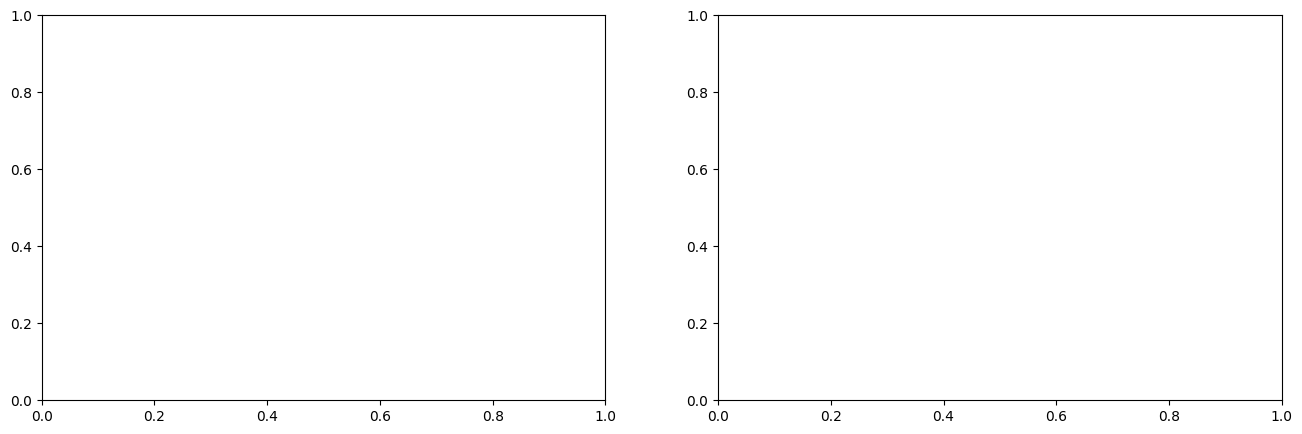

In [14]:
# --- Plot MIL results ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.plot(range(1, 41), aucs_max, label=f"Max-pool ({aucs_max[-1]:.3f})", color=PALETTE[3], linewidth=2)
ax.plot(range(1, 41), aucs_mean, label=f"Mean-pool ({aucs_mean[-1]:.3f})", color=PALETTE[1], linewidth=2, linestyle="--")
ax.plot(range(1, 41), aucs_attn, label=f"Attention ({aucs_attn[-1]:.3f})", color=PALETTE[0], linewidth=2)
ax.set_xlabel("Epoch"); ax.set_ylabel("Validation AUC")
ax.set_title("MIL on Real Pathology Bags", fontweight="bold")
ax.legend(fontsize=10); ax.set_ylim(0.4, 1.0)

ax = axes[1]
model_attn.eval()
pos_bags = [i for i, l in enumerate(labels_val) if l == 1][:2]
neg_bags = [i for i, l in enumerate(labels_val) if l == 0][:2]
for plot_i, bag_i in enumerate(pos_bags + neg_bags):
    bag = torch.tensor(bags_val[bag_i].reshape(-1, 1, 28, 28)).to(device)
    with torch.no_grad():
        _, attn_w = model_attn(bag)
    attn_np = attn_w.cpu().numpy()
    inst_labs = inst_labels_val[bag_i]
    order = np.argsort(attn_np)[::-1][:15]
    colors = [PALETTE[3] if inst_labs[j] == 1 else PALETTE[0] for j in order]
    x_pos = np.arange(15) + plot_i * 18
    label_str = "Pos" if labels_val[bag_i] == 1 else "Neg"
    ax.bar(x_pos, attn_np[order], color=colors, alpha=0.8, width=0.8)
    ax.text(x_pos[7], max(attn_np) * 0.9, f"Bag: {label_str}", ha="center", fontsize=8)
ax.set_xlabel("Instance (top 15 by attention)"); ax.set_ylabel("Attention Weight")
ax.set_title("Attention Weights (colored = true cancer tile)", fontweight="bold")
ax.set_xticks([])

fig.suptitle("Multi-Instance Learning on Real H&E Pathology (PathMNIST)", fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig("figures/fig5_mil_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Part 4: Augmentation Validity — Real Medical vs. Natural Images

**LECTURE FIGURE** (Figure 7)

The same augmentation can be valid for natural images and **invalid for medical images**.
We apply identical transforms to a natural image, a chest X-ray (ChestMNIST), and an
H&E pathology tile (PathMNIST) — all real images.

In [15]:
# ==============================================================================
# Figure 7: Augmentation comparison on REAL images
# ==============================================================================
import skimage.data

# Load real images
images = {}

# Natural image
cat = skimage.data.chelsea()
h, w = cat.shape[:2]; s = min(h, w)
cat = cat[(h-s)//2:(h+s)//2, (w-s)//2:(w+s)//2]
images["Natural (cat)"] = cat.astype(np.float32) / 255.0

# Real chest X-ray
cxr_sample = X_train[np.where(y_train == 1)[0][5]]
images["Chest X-ray (ChestMNIST)"] = cxr_sample

# Real pathology tile
path_sample = np.array(path_train[0][0]).astype(np.float32) / 255.0
images["H&E Pathology (PathMNIST)"] = path_sample

# Augmentations
def apply_augs(img):
    is_gray = img.ndim == 2
    results = {"Original": img}
    results["Horiz. flip"] = np.fliplr(img)
    results["Vert. flip"] = np.flipud(img)
    results["Rotate 15"] = ndimage_rotate(img, 15, reshape=False, mode="constant", cval=0) if is_gray else ndimage_rotate(img, 15, reshape=False, mode="constant", cval=0)
    if is_gray:
        results["Intensity jitter"] = np.clip(img * 1.4 + 0.1, 0, 1)
        results["Blur"] = gaussian_filter(img, sigma=3)
    else:
        results["Color jitter"] = np.clip(img * np.array([1.3, 0.8, 0.9]) + 0.05, 0, 1)
        results["Blur"] = gaussian_filter(img, sigma=(3, 3, 0))
    return results

validity = {
    "Natural (cat)": {"Horiz. flip": "V", "Vert. flip": "V", "Rotate 15": "V", "Intensity jitter": "V", "Color jitter": "V", "Blur": "~"},
    "Chest X-ray (ChestMNIST)": {"Horiz. flip": "V", "Vert. flip": "X", "Rotate 15": "V", "Intensity jitter": "X", "Color jitter": "X", "Blur": "X"},
    "H&E Pathology (PathMNIST)": {"Horiz. flip": "V", "Vert. flip": "V", "Rotate 15": "V", "Intensity jitter": "~", "Color jitter": "V", "Blur": "~"},
}

modality_names = list(images.keys())
fig, axes = plt.subplots(len(modality_names), 6, figsize=(18, 3 * len(modality_names)))

for row, mod_name in enumerate(modality_names):
    img = images[mod_name]
    augs = apply_augs(img)
    aug_names = list(augs.keys())
    val_key = mod_name

    for col, aug_name in enumerate(aug_names):
        ax = axes[row, col]
        aug_img = augs[aug_name]
        if aug_img.ndim == 2:
            ax.imshow(aug_img, cmap="gray", vmin=0, vmax=1)
        else:
            ax.imshow(np.clip(aug_img, 0, 1))
        ax.axis("off")

        if row == 0:
            ax.set_title(aug_name, fontsize=10)
        if col == 0:
            ax.set_ylabel(mod_name, fontsize=9)

        # Validity marker
        if aug_name != "Original":
            v = validity[val_key].get(aug_name, "?")
            color = PALETTE[2] if v == "V" else PALETTE[3] if v == "X" else PALETTE[4]
            marker = "VALID" if v == "V" else "INVALID" if v == "X" else "RISKY"
            ax.text(0.5, -0.04, marker, transform=ax.transAxes, ha="center", va="top",
                    fontsize=8, fontweight="bold", color=color)

fig.suptitle("Same Augmentations, Different Modalities: Validity Depends on Physics",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("figures/fig7_augmentation_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Vert. flip: valid for pathology (no orientation), INVALID for X-ray (mimics dextrocardia)")
print("Color jitter: valid for pathology (stain variation), INVALID for X-ray (intensity IS signal)")

ModuleNotFoundError: No module named 'skimage'

---
## Figure 6: Augmentation Ablation on Real X-Rays

**LECTURE FIGURE**

We train on real ChestMNIST X-rays with three strategies: no augmentation, valid-only
(horizontal flip + slight rotation), and invalid (adds vertical flip + intensity jitter).

In [16]:
def augment_batch(images, labels, strategy="none"):
    aug_images, aug_labels = list(images), list(labels)
    if strategy == "none":
        return np.array(aug_images), np.array(aug_labels)
    for img, lab in zip(images, labels):
        if strategy in ["valid", "invalid"]:
            if rng.random() < 0.5:
                aug_images.append(np.fliplr(img)); aug_labels.append(lab)
            if rng.random() < 0.5:
                aug_images.append(ndimage_rotate(img, rng.uniform(-10, 10), reshape=False, mode="constant", cval=0))
                aug_labels.append(lab)
        if strategy == "invalid":
            if rng.random() < 0.5:
                aug_images.append(np.flipud(img)); aug_labels.append(lab)
            if rng.random() < 0.5:
                aug_images.append(np.clip(img * rng.uniform(0.5, 1.5) + rng.uniform(-0.3, 0.3), 0, 1).astype(np.float32))
                aug_labels.append(lab)
    return np.array(aug_images), np.array(aug_labels)

results = {}
for strategy in ["none", "valid", "invalid"]:
    print(f"Training with strategy: {strategy}...")
    X_aug, y_aug = augment_batch(X_tr_sub, y_tr_sub, strategy=strategy)
    model = SimpleCNN()
    aucs = train_and_evaluate(model, X_aug, y_aug, X_val, y_val, epochs=20, lr=1e-3)
    results[strategy] = aucs
    print(f"  n={len(X_aug)}, final AUC: {aucs[-1]:.3f}")

fig, ax = plt.subplots(figsize=(10, 5))
styles = {"none": (PALETTE[4], "-", "No augmentation"), "valid": (PALETTE[2], "-", "Valid only"), "invalid": (PALETTE[3], "--", "Invalid included")}
for s, aucs in results.items():
    c, ls, lab = styles[s]
    ax.plot(range(1, 21), aucs, label=f"{lab} ({aucs[-1]:.3f})", color=c, linewidth=2, linestyle=ls)
ax.set_xlabel("Epoch"); ax.set_ylabel("Validation AUC")
ax.set_title("Augmentation Ablation on Real Chest X-Rays", fontweight="bold")
ax.legend(fontsize=10); ax.set_ylim(0.4, 1.0)
plt.tight_layout()
plt.savefig("figures/fig6_augmentation_ablation.png", dpi=150, bbox_inches="tight")
plt.show()

Training with strategy: none...


NameError: name 'X_tr_sub' is not defined

---
## Discussion

You're building a pneumonia detector for deployment across 5 hospitals with different X-ray machines.

1. **Transfer learning:** Given the Transfusion results on *real* ChestMNIST data, would you
   use ImageNet pre-training, domain-specific pre-training, or train from scratch?

2. **Segmentation:** We trained on Kvasir-SEG polyps. How would the class imbalance
   differ for liver tumors vs. whole organs? How would that affect your loss function choice?

3. **MIL:** In our PathMNIST experiment, only ~8% of tiles in positive bags were truly
   cancerous. In real WSIs with 10,000+ tiles, this drops to <1%. How does this affect
   mean-pooling vs. attention-based aggregation?

4. **Augmentation:** From Fig. 7, which augmentations would you use for retinal fundus images?
   For dermoscopy? Can you think of augmentations not shown that are valid for medical but not
   natural images (e.g., intensity windowing for CT)?

5. **Label quality:** Apply L21's five-question framework to each dataset we used today.
   Where is the label noise coming from? How does it limit what any model can learn?